In [3]:
import torch
import torch.nn as nn
import math

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [68]:
torch.arange(0, 3), torch.arange(0, 3).unsqueeze(1)

(tensor([0, 1, 2]),
 tensor([[0],
         [1],
         [2]]))

## 📐 Positional Encoding Matrix for the sequence *"I am a robot"*

| **Sequence** | **Index of Token** | **Positional Encoding Matrix** |
|--------------|--------------------|--------------------------------|
| I            | 0                  | $P_{00},\ P_{01},\ \ldots,\ P_{0d}$ |
| am           | 1                  | $P_{10},\ P_{11},\ \ldots,\ P_{1d}$ |
| a            | 2                  | $P_{20},\ P_{21},\ \ldots,\ P_{2d}$ |
| robot        | 3                  | $P_{30},\ P_{31},\ \ldots,\ P_{3d}$ |

---

Each row shows the **positional embedding vector** added to the token embedding at its position in the sentence.

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self,d_model, max_len = 10000, **kwargs):
        """
        d_model: dimension of the model. refers to the size of the vector representations (embeddings) used throughout a Transformer model.
        max_len: the maximum sequence length in NLP or time series models
        """
        super().__init__(**kwargs)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        print(position.size(), div_term.size(), pe.size())
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        print(pe.size())
        # registers a tensor as part of the module, but not as a learnable parameter
        # Should move to the right device (CPU/GPU) with .to(device)
        self.register_buffer('pe', pe)

    def forward(self,x):
        print(x.size(), self.pe.size())
        x = x + self.pe[:,:x.size(1)]
        print(x.size())
        return x
    
aa = PositionalEncoding(d_model=4,max_len=3)
aa.forward(torch.rand((1,3,4)))


torch.Size([3, 1]) torch.Size([2]) torch.Size([3, 4])
torch.Size([1, 3, 4])
torch.Size([1, 3, 4]) torch.Size([1, 3, 4])
torch.Size([1, 3, 4])


tensor([[[ 0.6887,  1.9750,  0.0900,  1.6000],
         [ 1.2369,  1.3727,  0.2397,  1.5121],
         [ 1.4222, -0.4031,  0.1042,  1.0917]]])

In [ ]:
class TransformerModel(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=512,
        nhead=8,
        n_layers=6,
        dim_feed_forward=2048,
        drop_out=0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=n_layers,
            num_decoder_layers=n_layers,
            dim_feedforward=dim_feed_forward,
            dropout=drop_out,
            batch_first=True,
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, memory_mask=None):
        src = self.src_embedding(src) * math.sqrt(self.d_model)
        # math.sqrt(self.d_model) This is done to control the variance of the embeddings and stabilize training. 4
        # Gradients don't vanish too quickly.
        tgt = self.tgt_embedding(tgt) * math.sqrt(self.d_model)

        src = self.pos_encoder(src)
        tgt = self.pos_encoder(tgt)

        output = self.transformer(
            src, tgt, src_mask=src_mask, tgt_mask=tgt_mask, memory_mask=memory_mask
        )
        return self.fc_out(output)

model = TransformerModel(
    src_vocab_size=100,
    tgt_vocab_size=100,
    d_model=16,
    nhead=8,
    n_layers=6,
    dim_feed_forward=2048,
    drop_out=0.0,
)

mmm = model(torch.randint(0, 100, (32, 10)), torch.randint(0, 100, (32, 10)))

torch.Size([10000, 1]) torch.Size([8]) torch.Size([10000, 16])
torch.Size([1, 10000, 16])
torch.Size([32, 10, 16]) torch.Size([1, 10000, 16])
torch.Size([32, 10, 16])
torch.Size([32, 10, 16]) torch.Size([1, 10000, 16])
torch.Size([32, 10, 16])


In [18]:
mmm

tensor([[[ 0.5059, -1.8854, -0.5773,  ..., -0.2420,  0.7341,  0.8617],
         [ 0.5716, -0.9286, -0.9272,  ..., -0.3130,  0.0802,  0.7652],
         [ 0.4438, -1.1842, -0.9013,  ..., -0.4673,  0.4626,  0.9266],
         ...,
         [ 0.9819, -1.3924, -0.6747,  ..., -0.0512,  0.1545,  0.8116],
         [ 0.4902, -1.8929, -0.6146,  ..., -0.2398,  0.7177,  0.9052],
         [ 0.6365, -1.5496, -0.9958,  ..., -0.3225,  0.4422,  0.7405]],

        [[-0.0338,  0.5696, -0.3698,  ..., -0.5212, -0.0075, -0.0346],
         [-0.0686,  0.4525, -0.3979,  ..., -0.4826,  0.0266, -0.0153],
         [-0.0592,  0.4511, -0.3037,  ..., -0.4952,  0.1510, -0.1004],
         ...,
         [-0.2564,  0.5455, -0.4292,  ..., -0.4047,  0.1030,  0.0379],
         [-0.1431,  0.4692, -0.3310,  ..., -0.3298, -0.0028,  0.0560],
         [-0.1010,  0.6639, -0.3878,  ..., -0.4308, -0.0611, -0.1008]],

        [[ 0.0071, -0.9479, -0.4500,  ...,  0.1104,  0.6467,  1.2498],
         [ 0.2110, -0.7031, -0.4682,  ..., -0

In [25]:
x = torch.tensor([1.9,2.0])
y = torch.rand((2,3))
z = torch.rand( (4,2,3))
print(z)
print(y)
z+y

tensor([[[0.4905, 0.5807, 0.9796],
         [0.9375, 0.8341, 0.1053]],

        [[0.4847, 0.8199, 0.9845],
         [0.0731, 0.6929, 0.3984]],

        [[0.7692, 0.6952, 0.8407],
         [0.3721, 0.9180, 0.9616]],

        [[0.4490, 0.7731, 0.8058],
         [0.0256, 0.0647, 0.7868]]])
tensor([[0.1962, 0.2970, 0.0667],
        [0.2970, 0.9380, 0.8246]])


tensor([[[0.6867, 0.8777, 1.0463],
         [1.2345, 1.7721, 0.9299]],

        [[0.6809, 1.1168, 1.0512],
         [0.3701, 1.6310, 1.2230]],

        [[0.9654, 0.9921, 0.9074],
         [0.6691, 1.8560, 1.7863]],

        [[0.6452, 1.0701, 0.8725],
         [0.3226, 1.0027, 1.6114]]])

In [12]:
(x+z)

tensor([2.1918, 2.7559])

In [13]:
x@y, y.T@x

(tensor([3.9000, 3.9000, 3.9000]), tensor([3.9000, 3.9000, 3.9000]))

In [18]:
a = torch.tensor(2.0, requires_grad = True)
b = a ** 3 + 5

b.backward()
a.grad

tensor(12.)

In [24]:
import torch.nn as nn
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10,2)

    def forward(self, x):
        return self.linear(x)
m = SimpleModel()


In [26]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(m.parameters(), lr=0.1)

In [27]:
for epoch in range(10):
    x = torch.rand((16,10))
    y = torch.rand((16,1))

    grad = m(x)
    loss = criterion(grad,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")


Epoch 0: Loss = 0.5401
Epoch 1: Loss = 0.2177
Epoch 2: Loss = 0.1815
Epoch 3: Loss = 0.1210
Epoch 4: Loss = 0.1707
Epoch 5: Loss = 0.1296
Epoch 6: Loss = 0.0955
Epoch 7: Loss = 0.0874
Epoch 8: Loss = 0.0875
Epoch 9: Loss = 0.1544


c:\Users\mamma\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [32]:
a= torch.tensor(3.0,requires_grad=True)
b = a**3 + 3* a**2

b.backward()
a.grad

tensor(45.)

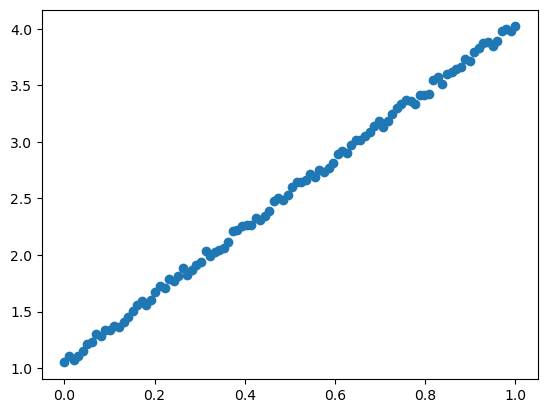

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
%matplotlib inline

torch.manual_seed(0)
x = torch.linspace(0,1,100).unsqueeze(1)
y = 3*x + 1 + 0.1 * torch.rand_like(x)
plt.scatter(x.numpy(), y.numpy(), label="Data")
plt.show()


In [9]:
class LinReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.mode = nn.Linear(1,1)
    def forward(self,x):
        return self.mode(x)

model = LinReg()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters())

for epoch in range(100):
    pred = model(x)
    loss = criterion(pred,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")

Epoch 0: loss = 2.3364
Epoch 10: loss = 2.2293
Epoch 20: loss = 2.1274
Epoch 30: loss = 2.0306
Epoch 40: loss = 1.9385
Epoch 50: loss = 1.8509
Epoch 60: loss = 1.7677
Epoch 70: loss = 1.6886
Epoch 80: loss = 1.6133
Epoch 90: loss = 1.5418


In [11]:
print("Learned weights:", model.mode.weight.item())
print("Learned bias:", model.mode.bias.item())

Learned weights: 1.0981260538101196
Learned bias: 0.9210964441299438


In [4]:
plt.scatter(x.numpy(), y.numpy(), label="Data")

: 